# Explosive vs. Continuous Percolation Phase Transitions in Complex Networks

This notebook explores continuous and discontinuous (explosive) percolation phase transitions in random networks.

### Background & Theoretical Foundations:
1. **Erdős–Rényi (ER) Percolation**:
   - Edges are added uniformly at random.
   - Exhibits a smooth, continuous (second-order) phase transition at critical threshold $t_c = 0.5$.
   - The giant component size scales as $S_{\text{max}} \sim (t - t_c)^\beta$ with $\beta = 1$.

2. **Achlioptas Product Rule (PR) Explosive Percolation**:
   - In each step, two candidate edges $e_1 = (u_1, v_1)$ and $e_2 = (u_2, v_2)$ are selected at random.
   - The edge that minimizes the product of component sizes $\min(S_{u_1} S_{v_1}, S_{u_2} S_{v_2})$ is added to the network.
   - Delays the formation of the giant component until a sudden, sharp ("explosive") jump occurs near $t_c \approx 0.888$.

3. **Bounded-Size / Best-of-Two (BF) Rule**:
   - A constrained edge addition rule prioritizing edges that connect components of unit size ($S = 1$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from percolation_simulation import DisjointSet, simulate_er, simulate_pr, simulate_bf

plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['font.size'] = 11
print("Percolation simulation tools loaded.")

Percolation simulation tools loaded.


## 1. Simulating Percolation Models ($N = 50,000$ Nodes)

We run the Disjoint-Set (Union-Find) percolation simulations across $N = 50,000$ nodes for Erdős–Rényi (ER), Product Rule (PR), and Bounded-Size (BF) mechanisms.

In [2]:
N_nodes = 50000

print(f"Running ER percolation simulation for N = {N_nodes:,}...")
t_er, gcc_er = simulate_er(N_nodes)

print(f"Running Achlioptas PR explosive percolation for N = {N_nodes:,}...")
t_pr, gcc_pr = simulate_pr(N_nodes)

print(f"Running Bounded-Size BF percolation for N = {N_nodes:,}...")
t_bf, gcc_bf = simulate_bf(N_nodes)

print("Simulations complete.")

Running ER percolation simulation for N = 50,000...
Running Achlioptas PR explosive percolation for N = 50,000...


Running Bounded-Size BF percolation for N = 50,000...


Simulations complete.


## 2. Giant Component Fraction ($S_{\max} / N$) vs. Edge Density ($r$)

We plot the evolution of the giant component fraction $C/N$ as a function of edge ratio $r = M / N$.

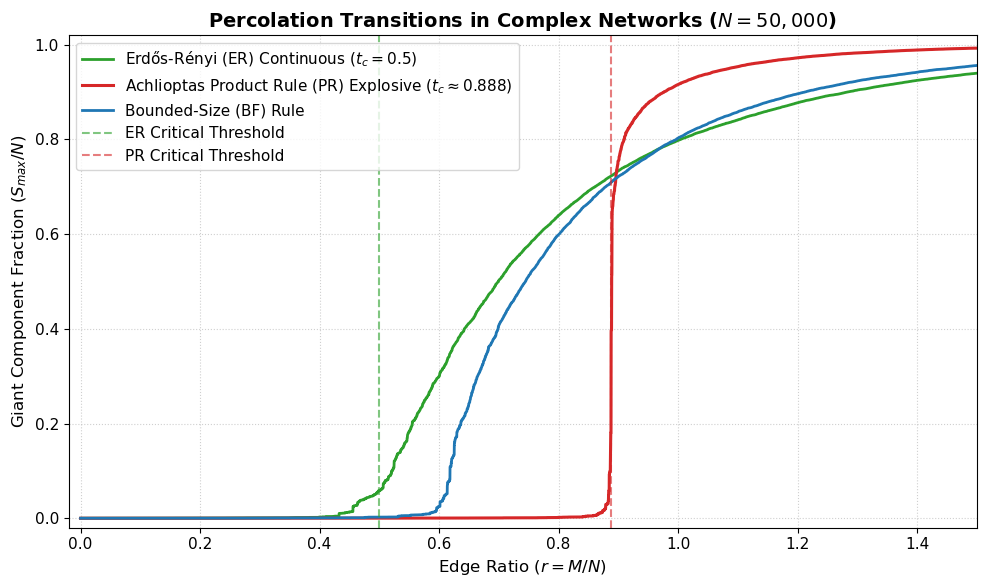

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(t_er, gcc_er, label="Erdős-Rényi (ER) Continuous ($t_c=0.5$)", color="#2ca02c", linewidth=2)
plt.plot(t_pr, gcc_pr, label="Achlioptas Product Rule (PR) Explosive ($t_c\\approx 0.888$)", color="#d62728", linewidth=2.2)
plt.plot(t_bf, gcc_bf, label="Bounded-Size (BF) Rule", color="#1f77b4", linewidth=2)

plt.axvline(0.5, color="#2ca02c", linestyle="--", alpha=0.6, label="ER Critical Threshold")
plt.axvline(0.888, color="#d62728", linestyle="--", alpha=0.6, label="PR Critical Threshold")

plt.xlabel("Edge Ratio ($r = M / N$)", fontsize=12)
plt.ylabel("Giant Component Fraction ($S_{max} / N$)", fontsize=12)
plt.title(f"Percolation Transitions in Complex Networks ($N = {N_nodes:,}$)", fontsize=14, fontweight="bold")
plt.xlim(-0.02, 1.5)
plt.ylim(-0.02, 1.02)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, fontsize=11, loc="upper left")
plt.tight_layout()
plt.savefig("percolation_phase_transitions.png", dpi=300)
plt.show()

## 3. Transition Sharpness: Numerical Derivative $\frac{d(S_{\max}/N)}{dt}$

To quantitatively demonstrate the "explosive" nature of the Achlioptas transition, we compute the numerical derivative of the giant component fraction with respect to edge density.

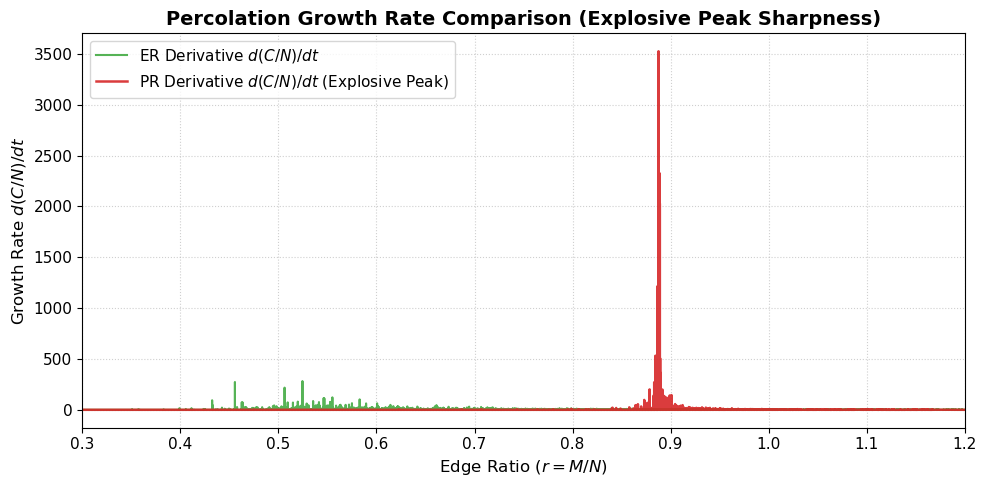

In [4]:
dt_er = np.gradient(gcc_er, t_er)
dt_pr = np.gradient(gcc_pr, t_pr)

plt.figure(figsize=(10, 5))
plt.plot(t_er, dt_er, label="ER Derivative $d(C/N)/dt$", color="#2ca02c", alpha=0.8, linewidth=1.5)
plt.plot(t_pr, dt_pr, label="PR Derivative $d(C/N)/dt$ (Explosive Peak)", color="#d62728", alpha=0.9, linewidth=1.8)

plt.xlabel("Edge Ratio ($r = M / N$)", fontsize=12)
plt.ylabel("Growth Rate $d(C/N)/dt$", fontsize=12)
plt.title("Percolation Growth Rate Comparison (Explosive Peak Sharpness)", fontsize=14, fontweight="bold")
plt.xlim(0.3, 1.2)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig("percolation_growth_rate.png", dpi=300)
plt.show()